<a href="https://colab.research.google.com/github/SAIRISAN123/Control-System-Interactive/blob/main/ControlSystemsInteractiveLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Robotics Control Systems: Open-Loop, Closed-Loop, and PID Control

This notebook introduces fundamental concepts in control systems, crucial for robotics. We will explore open-loop control, closed-loop (feedback) control, and the widely used Proportional-Integral-Derivative (PID) controller. Through Python code and visualizations, you'll understand how these systems work and how to implement them from scratch.

In [66]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider

# Set a consistent plot style
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Open-Loop Control

Open-loop control systems operate without any feedback mechanism. The controller sends a command to the system based on a pre-determined model or schedule, and the system executes it. There is no measurement of the output to determine if the desired state has been achieved.

**Example**: A toaster is an open-loop system. You set a timer, and it heats for that duration, regardless of how toasted the bread actually is. If the bread is already slightly toasted or if the heating element is faulty, it won't adjust.

### How it works:
Input → Controller → System → Output

### Limitations:
*   **No correction for disturbances:** External factors (e.g., changes in environment) are not compensated for.
*   **No correction for system inaccuracies:** If the system doesn't behave exactly as expected, the output will be off.
*   **Poor accuracy:** Generally less accurate than closed-loop systems, especially for dynamic processes.

### Simulation: Simple Heating System (Open-Loop)

Let's simulate a simple heating system where we provide a constant heater power (input), and the temperature of an object rises. The system's dynamics can be approximated by a first-order differential equation. For simplicity, we'll assume the rate of temperature change is proportional to the difference between the heat input and the current temperature.

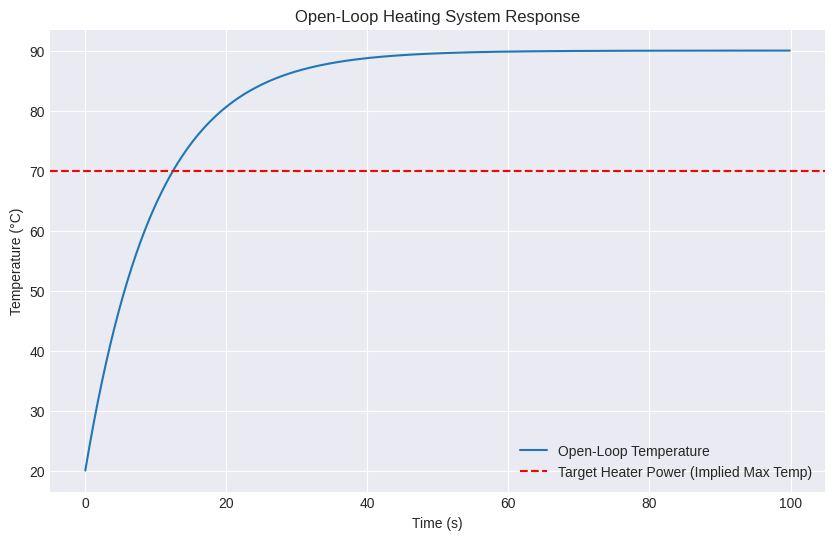

In [67]:
# Parameters for the heating system model
THERMAL_MASS = 10.0 # Represents how quickly temperature changes
AMBIENT_TEMP = 20.0 # Ambient temperature

def simulate_open_loop(target_power, duration, dt):
    """Simulates an open-loop heating system.

    Args:
        target_power (float): Constant heater power input.
        duration (float): Total simulation time in seconds.
        dt (float): Time step for simulation.

    Returns:
        tuple: (time_points, temperatures)
    """
    time_points = np.arange(0, duration, dt)
    temperatures = [AMBIENT_TEMP] # Start at ambient temperature
    current_temp = AMBIENT_TEMP

    for _ in time_points[1:]:
        # Simple first-order dynamics: dT/dt = (Input - current_temp) / THERMAL_MASS
        # Here, 'Input' is the heat added by the heater + effect of ambient
        # A more physical model: dT/dt = (HeaterPower - (current_temp - AMBIENT_TEMP) * HeatLossCoeff) / MassSpecificHeat
        # For simplicity, let's use: dT/dt = (target_power - (current_temp - AMBIENT_TEMP)) / THERMAL_MASS
        # Or even simpler for demonstration: dT/dt = (target_power * K - current_temp) / THERMAL_MASS
        # Let's assume target_power directly influences temperature increase rate relative to current temp

        # Using a simple model: temperature approaches a steady state based on input power
        # dT/dt = (K * Input - current_temp) / tau, where K*Input is the 'effective' max temp
        # Let's simplify: temperature change is proportional to the difference between target input and current temp
        # and also considers the ambient temperature pull.

        # A common way to model: dT/dt = (Heater_Effect - (current_temp - AMBIENT_TEMP) * HeatLossRate) / Mass
        # We'll use a simplified version for conceptual clarity:
        # The `target_power` will define a 'maximum reachable' temperature effectively.

        # Simplified first-order system where temperature moves towards target_power
        # The 'target_power' here is effectively setting the 'equilibrium temperature' the heater tries to reach
        # The system will try to reach `target_power` if `target_power` is treated as a target temperature from the heater

        # Let's use a model where `target_power` contributes directly to the temperature rise,
        # but heat also dissipates to the ambient environment.

        # dTemp/dt = (Heat_Input / Mass) - ((Temp - Ambient) * Heat_Loss_Rate / Mass)
        # Let's assume Heat_Input is proportional to target_power and Mass is THERMAL_MASS

        heat_input_effect = target_power / THERMAL_MASS # Heater effect
        heat_loss_effect = (current_temp - AMBIENT_TEMP) / THERMAL_MASS # Heat loss to ambient

        d_temp = (heat_input_effect - heat_loss_effect) * dt
        current_temp += d_temp
        temperatures.append(current_temp)

    return time_points, np.array(temperatures) # Fix: Removed [:-1] to match time_points length

# Simulation parameters
duration = 100.0  # seconds
dt = 0.1       # time step

# Open-loop control: Apply a constant heater power
heater_power_input = 70.0 # Units could be arbitrary, representing intensity of heating

time_open_loop, temp_open_loop = simulate_open_loop(heater_power_input, duration, dt)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(time_open_loop, temp_open_loop, label='Open-Loop Temperature')
plt.axhline(y=heater_power_input, color='r', linestyle='--', label='Target Heater Power (Implied Max Temp)')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Open-Loop Heating System Response')
plt.legend()
plt.grid(True)
plt.show()

### Open-Loop Limitations Explained

As you can see from the plot, the temperature rises and then stabilizes at a value. If our goal was to reach a specific temperature, say 60°C, and we only knew that `heater_power_input = 70` results in approximately 60°C, what happens if the `THERMAL_MASS` suddenly changes (e.g., a larger object is placed in the system), or if the `AMBIENT_TEMP` drops? The system would not reach the desired 60°C, and it would have no way of correcting itself because it doesn't measure the actual temperature. This is the fundamental drawback of open-loop control.

## 2. Closed-Loop (Feedback) Control

Closed-loop control systems, also known as feedback control systems, use the measured output of the system to adjust the input. This feedback allows the system to correct for errors and disturbances, striving to maintain the output at a desired setpoint.

### How it works:
Desired Value (Setpoint) → Error Calculation → Controller → System → Output → Measurement → Error Calculation (loop)

### Key Concepts:
*   **Setpoint (Desired Value):** The target value we want the system to achieve.
*   **Measurement:** The actual output of the system, sensed by a sensor.
*   **Error:** The difference between the setpoint and the measured output (`Error = Setpoint - Measurement`).
*   **Controller:** Uses the error to determine the appropriate input to send to the system to reduce the error.

### Advantages:
*   **Improved accuracy:** Continuously corrects for deviations.
*   **Disturbance rejection:** Can compensate for external disturbances.
*   **Robustness:** Less sensitive to variations in system parameters.

### Simulation: Simple Heating System (Closed-Loop)

Let's adapt our heating system simulation to include a basic feedback mechanism. The controller will now continuously adjust the heater power based on the difference between the desired temperature (setpoint) and the current measured temperature.

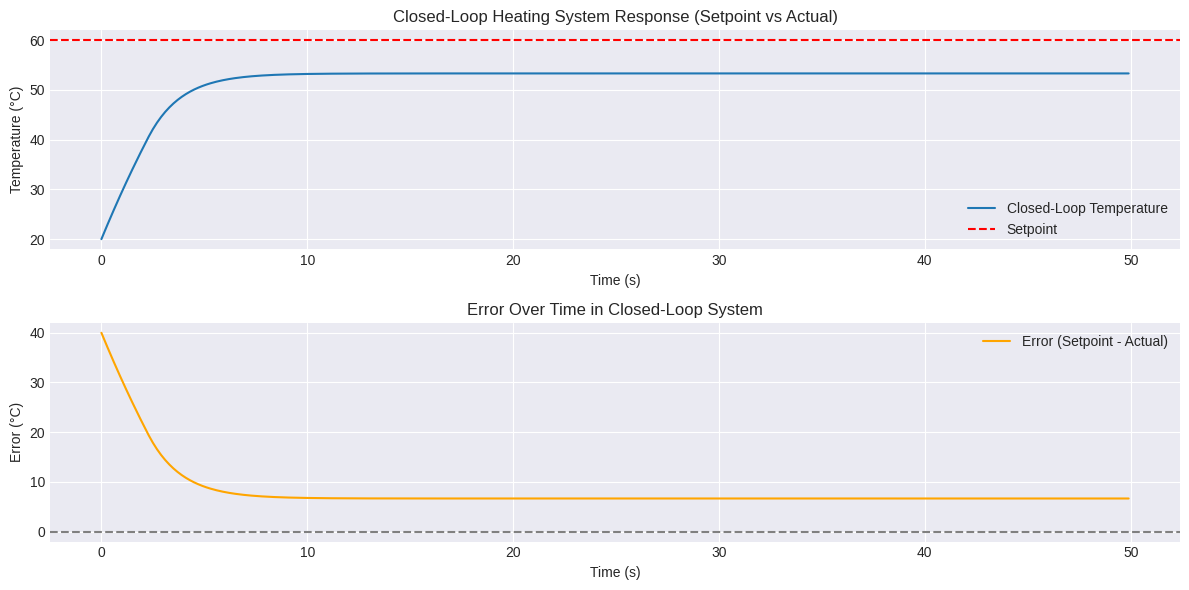

In [68]:
def simulate_closed_loop(setpoint_temp, duration, dt, control_gain=0.5):
    """Simulates a closed-loop heating system with basic proportional control.

    Args:
        setpoint_temp (float): The desired target temperature.
        duration (float): Total simulation time in seconds.
        dt (float): Time step for simulation.
        control_gain (float): How strongly the controller reacts to error (proportional gain).

    Returns:
        tuple: (time_points, temperatures, errors)
    """
    time_points = np.arange(0, duration, dt)
    temperatures = [AMBIENT_TEMP]
    errors = []
    current_temp = AMBIENT_TEMP

    for _ in time_points[1:]:
        error = setpoint_temp - current_temp
        errors.append(error)

        # Basic proportional controller: control_output = Kp * error
        # This output will be our 'heater_power_input'
        heater_power_input = control_gain * error # Control action based on error

        # Ensure heater power is not negative or excessively high (physical limits)
        heater_power_input = max(0.0, min(heater_power_input, 100.0)) # Assuming max power of 100

        # System dynamics (same as open-loop, but input is now from controller)
        heat_input_effect = heater_power_input / THERMAL_MASS
        heat_loss_effect = (current_temp - AMBIENT_TEMP) / THERMAL_MASS

        d_temp = (heat_input_effect - heat_loss_effect) * dt
        current_temp += d_temp
        temperatures.append(current_temp)

    errors.append(setpoint_temp - temperatures[-1]) # Add final error for consistent length
    return time_points, np.array(temperatures), np.array(errors) # Fix: Removed [:-1] to match time_points length

# Simulation parameters
duration = 50.0 # seconds
dt = 0.1      # time step
setpoint = 60.0 # Desired temperature (°C)
control_gain = 5.0 # Basic proportional gain for feedback

time_closed_loop, temp_closed_loop, errors_closed_loop = simulate_closed_loop(setpoint, duration, dt, control_gain)

# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(time_closed_loop, temp_closed_loop, label='Closed-Loop Temperature')
plt.axhline(y=setpoint, color='r', linestyle='--', label='Setpoint')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Closed-Loop Heating System Response (Setpoint vs Actual)')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(time_closed_loop, errors_closed_loop, label='Error (Setpoint - Actual)', color='orange')
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Error (°C)')
plt.title('Error Over Time in Closed-Loop System')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Comparison: Open-Loop vs. Closed-Loop

Let's compare the behavior of both systems side-by-side to highlight the benefits of feedback control.

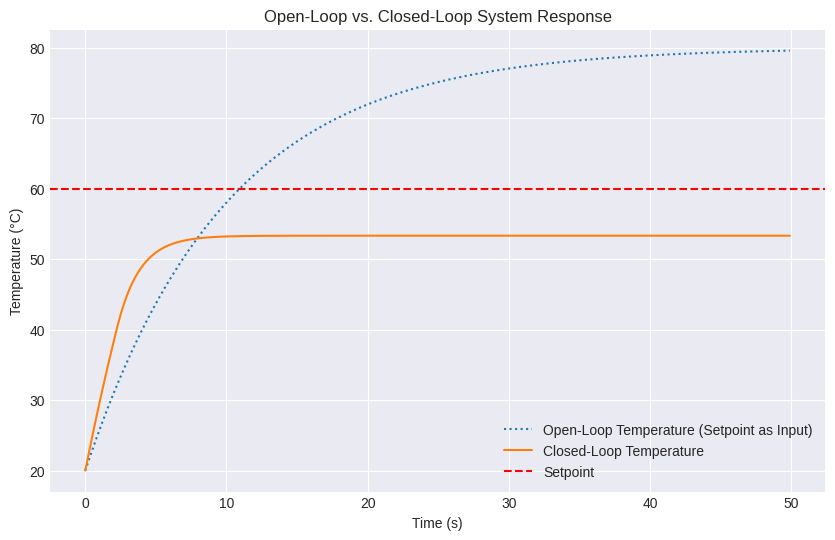

In [69]:
# Re-run open-loop for comparison with the same 'target power' if it were trying to reach the setpoint
# For fair comparison, let's see what `heater_power_input` would be if it caused ~setpoint in open loop
# In our simplified model, heater_power_input effectively IS the max temp it tries to reach.
# So, for open-loop, we'll set `heater_power_input` to the `setpoint` for comparison

time_open_loop_comp, temp_open_loop_comp = simulate_open_loop(setpoint, duration, dt)

plt.figure(figsize=(10, 6))
plt.plot(time_open_loop_comp, temp_open_loop_comp, label='Open-Loop Temperature (Setpoint as Input)', linestyle=':')
plt.plot(time_closed_loop, temp_closed_loop, label='Closed-Loop Temperature')
plt.axhline(y=setpoint, color='r', linestyle='--', label='Setpoint')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Open-Loop vs. Closed-Loop System Response')
plt.legend()
plt.grid(True)
plt.show()

Notice how the closed-loop system actively drives the temperature towards the `setpoint` and maintains it there, while the open-loop system, even when given an input *equal to the setpoint*, might not achieve or maintain it accurately due to unmodeled dynamics or disturbances. The open-loop also takes longer to reach the setpoint (or implied setpoint) and might have steady-state error if the input isn't perfectly calibrated.

## 3. PID Control System

PID (Proportional-Integral-Derivative) control is the most common control algorithm used in industrial control systems and is widely applicable in robotics. It's a closed-loop control mechanism that continuously calculates an 'error value' as the difference between a desired setpoint and a measured process variable. The controller then attempts to minimize the error by adjusting the process control inputs.

The PID controller works by summing three components: Proportional, Integral, and Derivative.

### Understanding PID Components:

*   ### P (Proportional) Term: `Kp * error`
    *   **Intuition:** This term makes the control output proportional to the current error. If the error is large, the correction is large; if the error is small, the correction is small. It's like pressing the accelerator harder when you're far from the speed limit, and gently when you're close.
    *   **Effect:** Primarily responsible for the speed of response. A higher `Kp` makes the system respond faster, but too high can lead to oscillations and instability.
    *   **Limitation:** Often results in a **steady-state error** (offset) where the system never quite reaches the setpoint, especially in the presence of disturbances or when the control effort needs to be sustained.

*   ### I (Integral) Term: `Ki * ∫error dt`
    *   **Intuition:** This term considers the *accumulated* error over time. If there's a persistent small error, the integral term will grow, eventually driving the system to eliminate that error. It's like remembering how far off you've been in the past and making a stronger correction if the error has been consistent.
    *   **Effect:** Eliminates steady-state error. A higher `Ki` helps remove offset faster, but too high can cause overshoot and slow oscillations.
    *   **Limitation:** Can make the system slower to respond and more prone to overshoot if not tuned carefully.

*   ### D (Derivative) Term: `Kd * d(error)/dt`
    *   **Intuition:** This term predicts future error based on the current *rate of change* of the error. If the error is rapidly increasing, the derivative term applies a strong counter-force to slow it down. It's like braking early when you see you're approaching a stop sign too quickly.
    *   **Effect:** Improves transient response, reduces overshoot, and increases stability by damping oscillations. It reacts to how quickly the error is changing.
    *   **Limitation:** Sensitive to noise in the measurement, as differentiation amplifies noise. Can make the system unstable if `Kd` is too high and noise is present.

### The complete PID control output is: `Output = Kp * error + Ki * ∫error dt + Kd * d(error)/dt`

### Implementing the PID Controller Class

We'll create a Python class for a PID controller to encapsulate its logic and state (like integral error and previous error).

In [70]:
class PIDController:
    """A simple PID controller implementation."""
    def __init__(self, Kp, Ki, Kd, output_limits=(0, 100), dt=0.1):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.output_limits = output_limits # Max/min output for the actuator (e.g., heater power)
        self.dt = dt                     # Time step

        self._integral = 0.0
        self._previous_error = 0.0

    def calculate(self, setpoint, process_variable):
        """Calculates the PID control output.

        Args:
            setpoint (float): The desired target value.
            process_variable (float): The current measured value from the system.

        Returns:
            float: The control output to be applied to the system.
        """
        error = setpoint - process_variable

        # Proportional term
        P_term = self.Kp * error

        # Integral term
        self._integral += error * self.dt
        # Apply integral wind-up protection (optional but good practice)
        if self.Ki != 0: # Fix: Only apply if Ki is not zero to prevent ZeroDivisionError
            if self._integral > self.output_limits[1] / self.Ki: # Prevent integral from growing too large
                self._integral = self.output_limits[1] / self.Ki
            elif self._integral < self.output_limits[0] / self.Ki:
                self._integral = self.output_limits[0] / self.Ki
        I_term = self.Ki * self._integral

        # Derivative term
        D_term = self.Kd * (error - self._previous_error) / self.dt
        self._previous_error = error

        # Total PID output
        output = P_term + I_term + D_term

        # Clamp output to defined limits
        output = max(self.output_limits[0], min(output, self.output_limits[1]))

        return output

    def reset(self):
        """Resets the integral and previous error terms."""
        self._integral = 0.0
        self._previous_error = 0.0

### System Model for PID Control: Temperature Control

We will continue to use our simplified heating system model. The goal is to reach and maintain a specific target temperature using our PID controller to adjust the heater's power.

In [71]:
# System model function (similar to before, but now takes controller output)
def run_system_simulation(controller, setpoint, duration, dt, initial_temp=AMBIENT_TEMP):
    """Simulates the heating system with a given controller.

    Args:
        controller (PIDController): The PID controller instance.
        setpoint (float): The desired target temperature.
        duration (float): Total simulation time in seconds.
        dt (float): Time step for simulation.
        initial_temp (float): Starting temperature.

    Returns:
        tuple: (time_points, temperatures, errors, control_outputs)
    """
    time_points = np.arange(0, duration, dt)
    temperatures = [initial_temp]
    errors = []
    control_outputs = []
    current_temp = initial_temp

    controller.reset() # Reset controller state for a fresh simulation

    for t in time_points[1:]:
        error = setpoint - current_temp
        errors.append(error)

        # Get control action from PID controller
        heater_power_input = controller.calculate(setpoint, current_temp)
        control_outputs.append(heater_power_input)

        # System dynamics (updated with PID output)
        heat_input_effect = heater_power_input / THERMAL_MASS
        heat_loss_effect = (current_temp - AMBIENT_TEMP) / THERMAL_MASS

        d_temp = (heat_input_effect - heat_loss_effect) * dt
        current_temp += d_temp
        temperatures.append(current_temp)

    errors.append(setpoint - temperatures[-1]) # Add final error for consistent length
    control_outputs.append(control_outputs[-1] if control_outputs else 0) # Final control output

    return time_points, np.array(temperatures), np.array(errors), np.array(control_outputs) # Fix: Removed [:-1] to match time_points length

### P-only Control

Let's start by using only the Proportional term (`Kp`). We expect to see a relatively fast response but potentially a steady-state error.

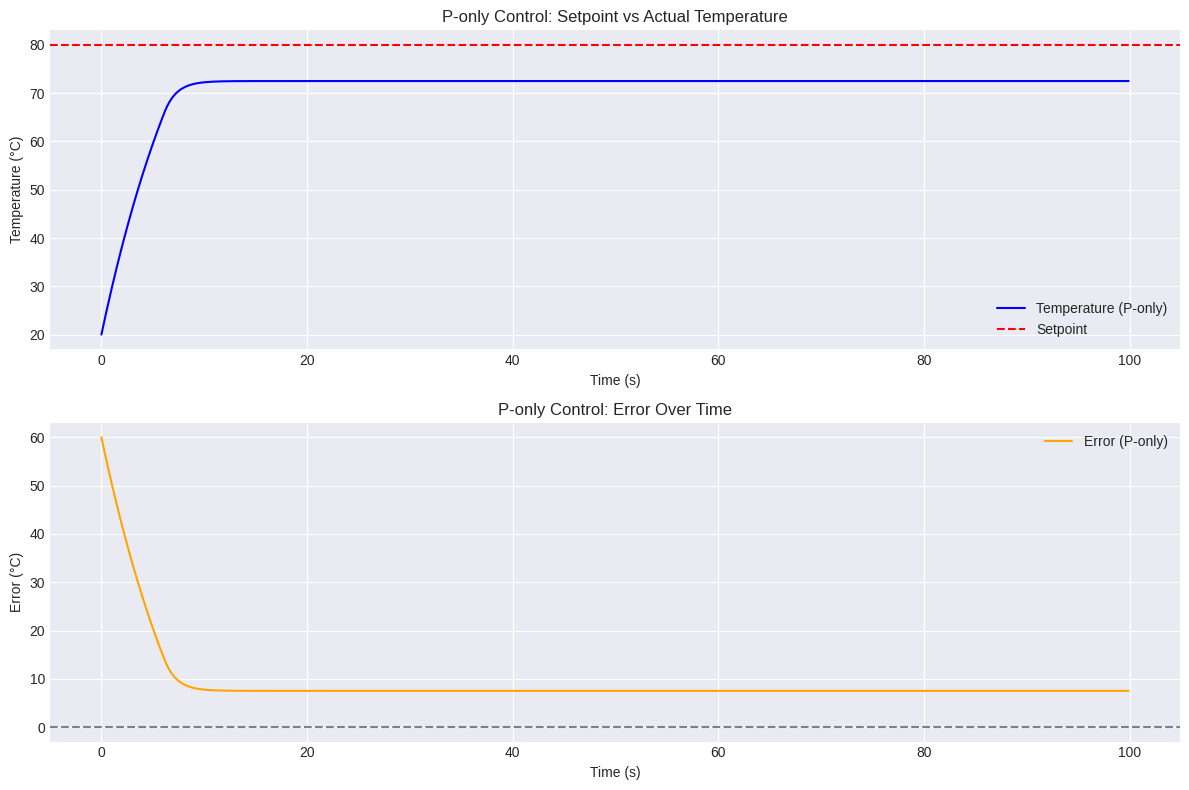

In [72]:
# Simulation parameters
setpoint = 80.0 # Desired temperature (°C)
duration = 100.0 # seconds
dt = 0.1       # time step

# P-only controller gains
Kp_p_only = 7.0
Ki_p_only = 0.0
Kd_p_only = 0.0

pid_p_only = PIDController(Kp_p_only, Ki_p_only, Kd_p_only, dt=dt)

time_p_only, temp_p_only, errors_p_only, controls_p_only = run_system_simulation(pid_p_only, setpoint, duration, dt)

# Plotting
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(time_p_only, temp_p_only, label='Temperature (P-only)', color='blue')
plt.axhline(y=setpoint, color='red', linestyle='--', label='Setpoint')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('P-only Control: Setpoint vs Actual Temperature')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(time_p_only, errors_p_only, label='Error (P-only)', color='orange')
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Error (°C)')
plt.title('P-only Control: Error Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

As expected, the P-only controller quickly reacts to the error, but it stabilizes with a noticeable **steady-state error** (the temperature doesn't quite reach the setpoint, and the error doesn't go to zero).

### PI Control

Now, let's add the Integral term (`Ki`) to eliminate the steady-state error. We'll use the same `Kp` and add `Ki`.

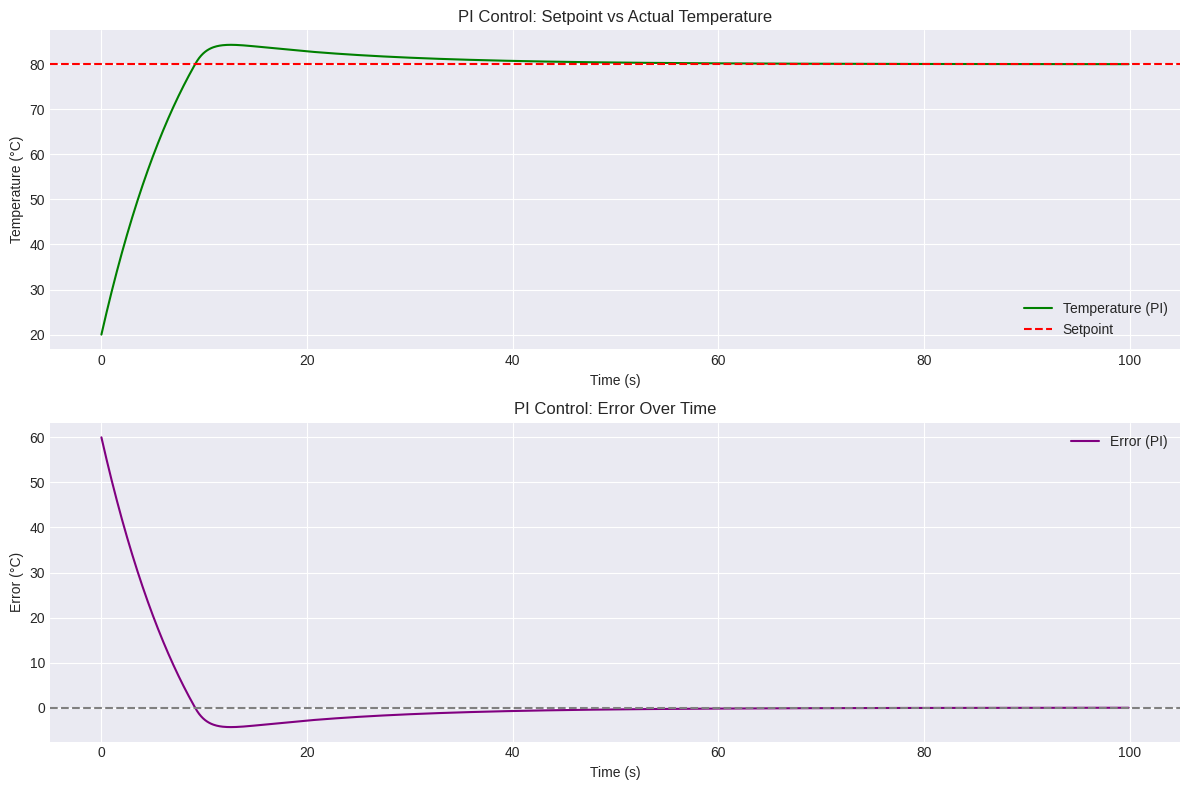

In [73]:
# PI controller gains (keeping Kp, adding Ki)
Kp_pi = 7.0
Ki_pi = 0.5 # Added integral gain
Kd_pi = 0.0

pid_pi = PIDController(Kp_pi, Ki_pi, Kd_pi, dt=dt)

time_pi, temp_pi, errors_pi, controls_pi = run_system_simulation(pid_pi, setpoint, duration, dt)

# Plotting
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(time_pi, temp_pi, label='Temperature (PI)', color='green')
plt.axhline(y=setpoint, color='red', linestyle='--', label='Setpoint')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('PI Control: Setpoint vs Actual Temperature')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(time_pi, errors_pi, label='Error (PI)', color='purple')
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Error (°C)')
plt.title('PI Control: Error Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

With the Integral term, the steady-state error is eliminated! The temperature eventually reaches the setpoint. However, you might observe a bit more overshoot compared to P-only control, or a slightly slower approach to the setpoint once it's close.

### PID Control

Finally, let's add the Derivative term (`Kd`) to improve the system's transient response, reduce overshoot, and make it more stable. We'll use the same `Kp` and `Ki`, and add `Kd`.

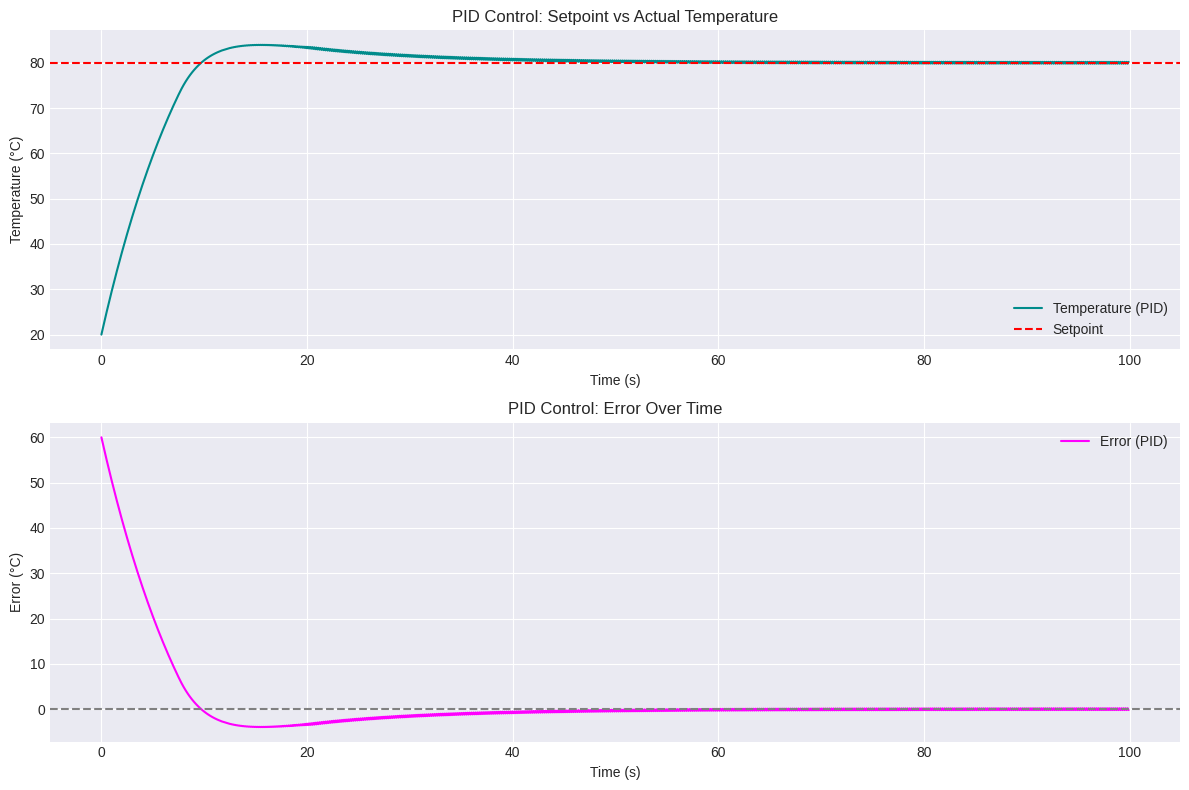

In [74]:
# PID controller gains (adding Kd)
Kp_pid = 7.0
Ki_pid = 0.5
Kd_pid = 10.0 # Added derivative gain

pid_pid = PIDController(Kp_pid, Ki_pid, Kd_pid, dt=dt)

time_pid, temp_pid, errors_pid, controls_pid = run_system_simulation(pid_pid, setpoint, duration, dt)

# Plotting
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(time_pid, temp_pid, label='Temperature (PID)', color='darkcyan')
plt.axhline(y=setpoint, color='red', linestyle='--', label='Setpoint')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('PID Control: Setpoint vs Actual Temperature')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(time_pid, errors_pid, label='Error (PID)', color='magenta')
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Error (°C)')
plt.title('PID Control: Error Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

With the Derivative term, the system's response is often smoother and faster, with reduced overshoot. `Kd` anticipates changes, effectively 'damping' the system's reaction.

### Comparison of P, PI, and PID Control Responses

Let's visualize all three control strategies on a single plot to clearly see their differences and improvements.

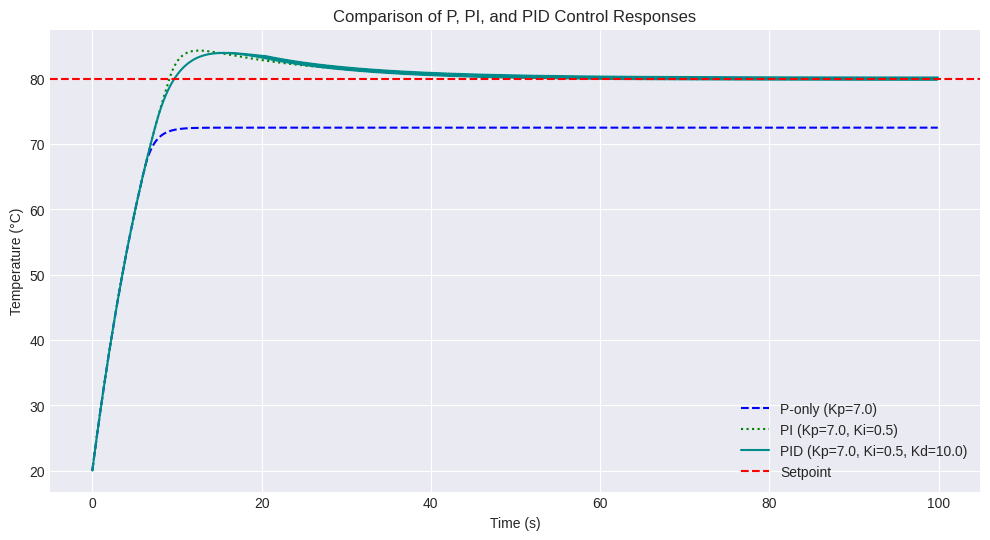

In [75]:
plt.figure(figsize=(12, 6))
plt.plot(time_p_only, temp_p_only, label=f'P-only (Kp={Kp_p_only})', linestyle='--', color='blue')
plt.plot(time_pi, temp_pi, label=f'PI (Kp={Kp_pi}, Ki={Ki_pi})', linestyle=':', color='green')
plt.plot(time_pid, temp_pid, label=f'PID (Kp={Kp_pid}, Ki={Ki_pid}, Kd={Kd_pid})', color='darkcyan')

plt.axhline(y=setpoint, color='red', linestyle='--', label='Setpoint')

plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Comparison of P, PI, and PID Control Responses')
plt.legend()
plt.grid(True)
plt.show()

From the comparison, you can observe:
*   **P-only:** Fast initial response but settles with a steady-state error.
*   **PI:** Eliminates steady-state error, but might have more overshoot or a slower approach to the setpoint than a well-tuned PID.
*   **PID:** Achieves the setpoint with good speed, minimal overshoot, and no steady-state error, representing a balanced and robust control.

## Bonus: Interactive PID Tuning with Sliders

One of the best ways to understand the impact of Kp, Ki, and Kd is to experiment with them. We'll use `ipywidgets` to create sliders that let you adjust these gains in real-time and see how they affect the system's response.

In [ ]:
def interactive_pid_tuning(Kp, Ki, Kd, setpoint=80.0, duration=100.0, dt=0.1):
    """Runs a PID simulation with interactively adjustable gains and plots the result."""
    pid_controller = PIDController(Kp, Ki, Kd, dt=dt)

    time_points, temperatures, errors, control_outputs = run_system_simulation(pid_controller, setpoint, duration, dt)

    clear_output(wait=True)
    fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # Plot Temperature vs Setpoint
    axs[0].plot(time_points, temperatures, label='Actual Temperature', color='teal')
    axs[0].axhline(y=setpoint, color='red', linestyle='--', label='Setpoint')
    axs[0].set_ylabel('Temperature (°C)')
    axs[0].set_title(f'PID Control (Kp={Kp:.2f}, Ki={Ki:.2f}, Kd={Kd:.2f})')
    axs[0].legend()
    axs[0].grid(True)

    # Plot Error over time
    axs[1].plot(time_points, errors, label='Error (Setpoint - Actual)', color='coral')
    axs[1].axhline(y=0, color='gray', linestyle='--')
    axs[1].set_xlabel('Time (s)')
    axs[1].set_ylabel('Error (°C)')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

# Create interactive sliders
Kp_slider = FloatSlider(min=0.0, max=20.0, step=0.1, value=7.0, description='Kp')
Ki_slider = FloatSlider(min=0.0, max=2.0, step=0.01, value=0.5, description='Ki')
Kd_slider = FloatSlider(min=0.0, max=50.0, step=0.5, value=10.0, description='Kd')

print("Adjust the sliders below to see how Kp, Ki, and Kd affect the PID controller's performance:")
interact(interactive_pid_tuning, Kp=Kp_slider, Ki=Ki_slider, Kd=Kd_slider);

### Tips for Tuning with the Sliders:

1.  **Start with P-only:** Set `Ki` and `Kd` to 0. Increase `Kp` until the response is fast but starts to oscillate a bit. Note the steady-state error.
2.  **Add I:** Gradually increase `Ki`. You'll see the steady-state error diminish and eventually disappear. Be careful not to increase too much, or the system will overshoot significantly and oscillate slowly.
3.  **Add D:** Gradually increase `Kd`. This should help reduce overshoot and damp out oscillations, making the response faster and more stable.
4.  **Iterate:** Tuning is often an iterative process. Adjust Kp, Ki, and Kd in small increments, observing the impact on rise time, overshoot, settling time, and steady-state error.

This interactive demonstration provides a powerful way to build intuition for how each PID gain contributes to the overall control system behavior, a fundamental skill in robotics and automation.

### Custom PID Gain Comparison

Use this section to define specific sets of PID gains (`Kp`, `Ki`, `Kd`) and compare their temperature responses on a single plot. This is useful for analyzing the impact of different tuning parameters without using the interactive slider.

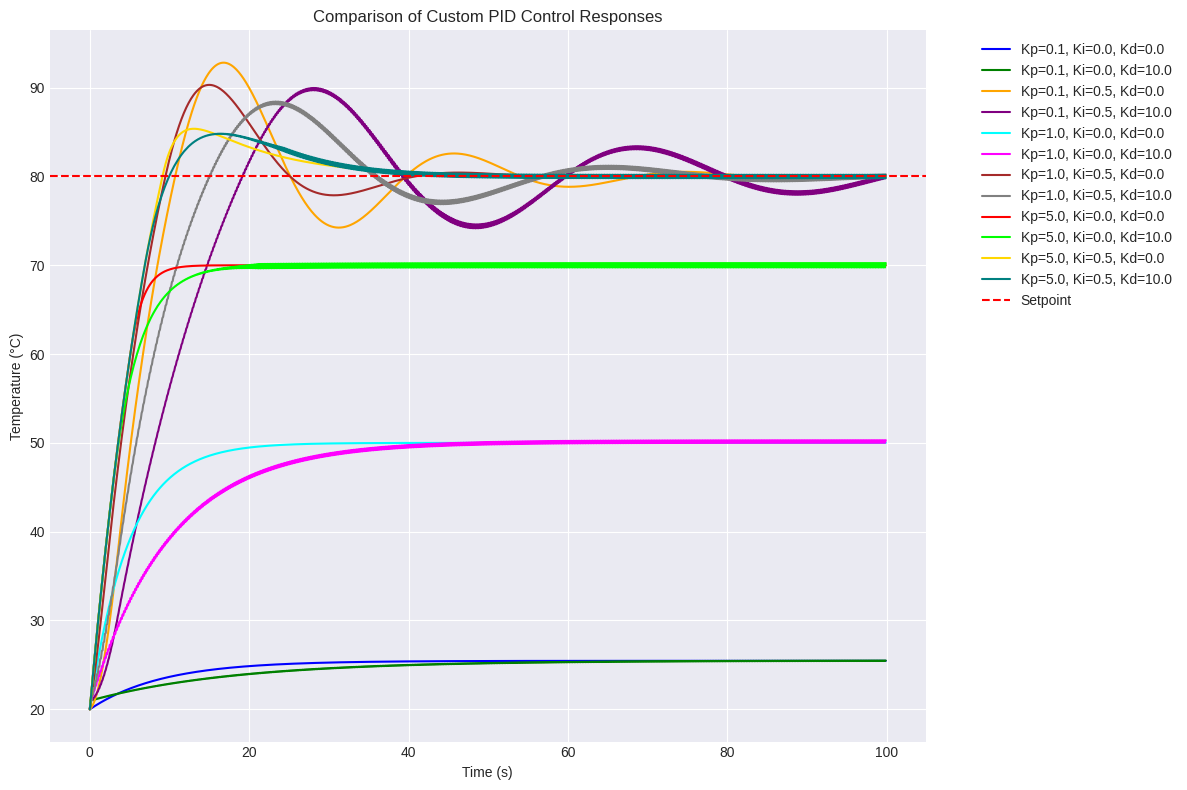

In [79]:
# Define the sets of PID gains you want to compare
# Each tuple is (Kp, Ki, Kd)
kp = [0.1, 1.0, 5.0]
ki = [0.0, 0.5]
kd = [0.0, 10.0]

# Generate all combinations of Kp, Ki, Kd
pid_gain_sets = [(k_p, k_i, k_d) for k_p in kp for k_i in ki for k_d in kd]

setpoint = 80.0
duration = 100.0
dt = 0.1

plt.figure(figsize=(12, 8))
colors = ['blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'brown', 'gray', 'red', 'lime', 'gold', 'teal'] # Expanded colors for more combinations

results = []

for i, (Kp, Ki, Kd) in enumerate(pid_gain_sets):
    pid_controller = PIDController(Kp, Ki, Kd, dt=dt)
    time_points, temperatures, _, _ = run_system_simulation(pid_controller, setpoint, duration, dt)
    results.append({'time': time_points, 'temp': temperatures, 'label': f'Kp={Kp}, Ki={Ki}, Kd={Kd}'})

for i, res in enumerate(results):
    plt.plot(res['time'], res['temp'], label=res['label'], color=colors[i % len(colors)])

plt.axhline(y=setpoint, color='red', linestyle='--', label='Setpoint')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Comparison of Custom PID Control Responses')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside
plt.grid(True)
plt.tight_layout()
plt.show()